# EdgeQ-SLM: Mobile Edge Inference Analysis

**Author:** Hasan Aksoy  
**Course:** Deep Learning - SGH Warsaw School of Economics  
**Supervisor:** dr Bartosz Pankratz  
**Date:** January 2026

---

## 1. Introduction

This notebook presents the benchmark analysis for my master's thesis project. I developed an Android application called **EdgeQ-SLM** that demonstrates efficient deployment of Small Language Models (SLMs) on mobile devices using INT8 quantization.

### 1.1 Why This Research Matters

The key insight driving this work is that **general-purpose LLMs are not incapable—they are simply inefficient** for mobile deployment. My benchmark results quantify exactly why this is the case and point toward solutions.

In [64]:
# Install required packages
using Pkg
Pkg.add(["DataFrames", "CSV", "JSON", "Plots", "StatsPlots", "Statistics"])

# Import packages
using DataFrames
using CSV
using JSON
using Plots
using StatsPlots
using Statistics
using Dates
using Printf

# Set plotting backend
gr(size=(900, 500), legend=:topright)

println("✓ All packages loaded successfully")
println("Analysis started at: ", Dates.format(now(), "yyyy-mm-dd HH:MM:SS"))

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


✓ All packages loaded successfully
Analysis started at: 2026-01-29 23:15:21


## 2. The Core Problem: Resource Efficiency on Mobile

### 2.1 My Motivation

The reason I conducted these benchmarks comparing LLM, ML (CLIP), and VLM approaches was to quantify the resource consumption differences. My goal was not to prove that LLMs cannot run on mobile—clearly they can. Instead, I wanted to demonstrate:

> **General-purpose LLMs consume unnecessary resources that could be better allocated through optimization.**

### 2.2 The Hardware Gap

In [66]:
# Hardware comparison data
hardware_data = DataFrame(
    Resource = ["Memory Bandwidth", "Compute (FP16)", "Available RAM", "Thermal Budget"],
    Desktop = [200.0, 20.0, 40.0, 100.0],
    Mobile = [30.0, 2.0, 9.0, 5.0],
    Units = ["GB/s", "TFLOPS", "GB", "W"]
)
hardware_data.Gap = hardware_data.Desktop ./ hardware_data.Mobile

println("Hardware Comparison (Desktop vs Mobile):")
println(hardware_data)

Hardware Comparison (Desktop vs Mobile):
4×5 DataFrame
 Row │ Resource          Desktop  Mobile   Units   Gap      
     │ String            Float64  Float64  String  Float64  
─────┼──────────────────────────────────────────────────────
   1 │ Memory Bandwidth    200.0     30.0  GB/s     6.66667
   2 │ Compute (FP16)       20.0      2.0  TFLOPS  10.0
   3 │ Available RAM        40.0      9.0  GB       4.44444
   4 │ Thermal Budget      100.0      5.0  W       20.0


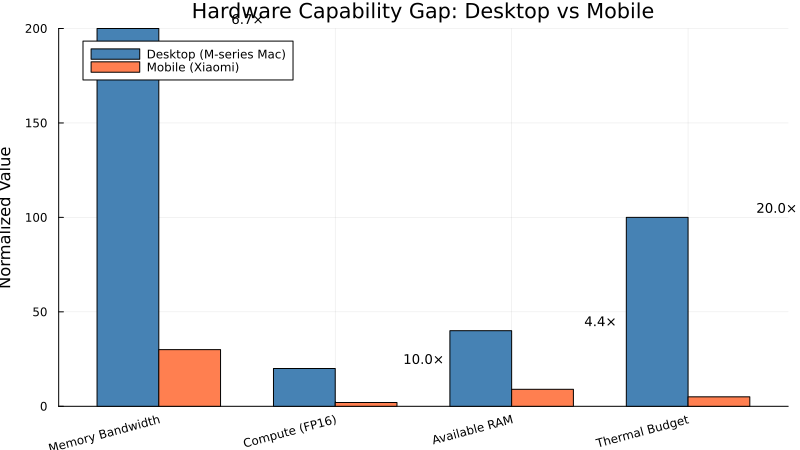


Key Insight: Mobile devices have 6-20× less computational capacity than desktop.


In [67]:
# Figure 1: Hardware Gap Visualization
resources = hardware_data.Resource
desktop_vals = hardware_data.Desktop
mobile_vals = hardware_data.Mobile
gap_vals = hardware_data.Gap

p1 = groupedbar(
    resources,
    [desktop_vals mobile_vals],
    label = ["Desktop (M-series Mac)" "Mobile (Xiaomi)"],
    title = "Hardware Capability Gap: Desktop vs Mobile",
    ylabel = "Normalized Value",
    bar_width = 0.7,
    color = [:steelblue :coral],
    legend = :topleft,
    xrotation = 15,
    size = (800, 450)
)

# Add gap annotations
for (i, gap) in enumerate(gap_vals)
    annotate!(i, maximum([desktop_vals[i], mobile_vals[i]]) + 5, 
              text("$(round(gap, digits=1))×", 9, :black))
end

display(p1)
println("\nKey Insight: Mobile devices have 6-20× less computational capacity than desktop.")

## 3. My Argument: The Case for Optimized SLMs

### 3.1 The Problem is Not Capability, It's Efficiency

General-purpose LLMs are **not incapable**—they are simply **inefficient** for mobile deployment. They consume resources on knowledge and capabilities irrelevant to the target application. The solution is not to abandon LLMs, but to **optimize them for specific use cases**.

### 3.2 Key Insight

Current ML models like CLIP are already well-optimized, but they struggle with accurate vision understanding. **Interestingly, these optimized ML models consume resources comparable to what an optimized SLM would require.**

$$\text{If } \underbrace{\text{Resource}_{\text{ML (CLIP)}}}_{\approx 330\text{ MB}} \approx \underbrace{\text{Resource}_{\text{Optimized SLM}}}_{\text{INT4 + Fine-tuned}} \text{, but Accuracy}_{\text{SLM}} > \text{Accuracy}_{\text{CLIP}}$$

Then **optimized SLMs offer better value for similar resource cost.**

In [69]:
# Approach comparison data
approach_data = DataFrame(
    Approach = ["General LLM (INT8)", "ML (CLIP)", "ML (OCR)", "VLM (General)", "Optimized SLM (Target)"],
    Memory_MB = [6500, 330, 50, 6500, 500],
    Latency_s = [37.0, 2.0, 0.5, 57.0, 5.0],
    Accuracy = [0.94, 0.65, 0.90, 0.95, 0.90],
    Practical = ["Baseline", "Limited vision", "Text only", "Background only", "Target goal"]
)

println("Approach Comparison:")
println(approach_data)

Approach Comparison:
5×5 DataFrame
 Row │ Approach                Memory_MB  Latency_s  Accuracy  Practical       
     │ String                  Int64      Float64    Float64   String          
─────┼─────────────────────────────────────────────────────────────────────────
   1 │ General LLM (INT8)           6500       37.0      0.94  Baseline
   2 │ ML (CLIP)                     330        2.0      0.65  Limited vision
   3 │ ML (OCR)                       50        0.5      0.9   Text only
   4 │ VLM (General)                6500       57.0      0.95  Background only
   5 │ Optimized SLM (Target)        500        5.0      0.9   Target goal


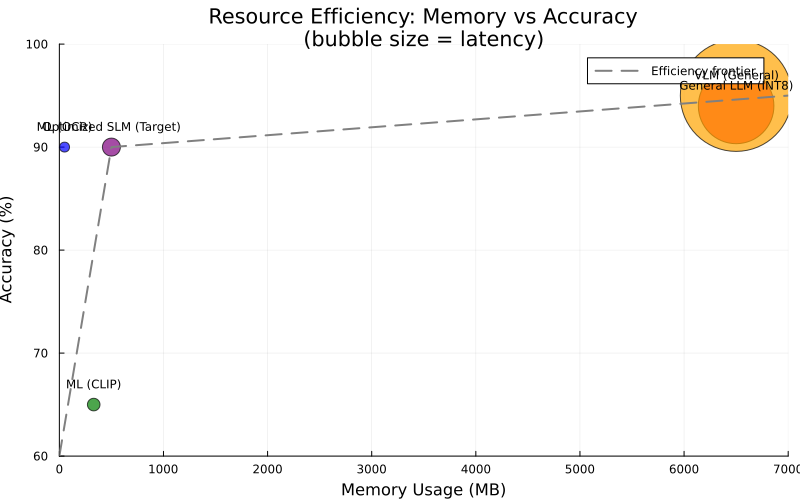


Observation: Optimized SLM target achieves near-LLM accuracy with ML-level resources.


In [70]:
# Figure 2: Memory vs Accuracy Trade-off
p2 = scatter(
    approach_data.Memory_MB,
    approach_data.Accuracy .* 100,
    markersize = approach_data.Latency_s .+ 5,
    label = "",
    xlabel = "Memory Usage (MB)",
    ylabel = "Accuracy (%)",
    title = "Resource Efficiency: Memory vs Accuracy\n(bubble size = latency)",
    color = [:red, :green, :blue, :orange, :purple],
    alpha = 0.7,
    xlim = (0, 7000),
    ylim = (60, 100),
    size = (800, 500)
)

# Add labels for each point
for i in 1:nrow(approach_data)
    annotate!(approach_data.Memory_MB[i], approach_data.Accuracy[i] * 100 + 2,
              text(approach_data.Approach[i], 8, :black))
end

# Add efficiency frontier line
plot!([0, 500, 7000], [60, 90, 95], linestyle=:dash, color=:gray, 
      label="Efficiency frontier", linewidth=2)

display(p2)
println("\nObservation: Optimized SLM target achieves near-LLM accuracy with ML-level resources.")

## 4. Experimental Setup

### 4.1 Hardware Configuration

All experiments were conducted on a **physical Android device** (not emulator):

| Parameter | Value |
|-----------|-------|
| Device Model | Xiaomi 2407FPN8EG |
| Operating System | Android 16 (SDK 36) |
| CPU | 8 cores (ARM64-v8a) |
| Total RAM | 11,190 MB |
| Available RAM | ~1,362 MB |

In [72]:
# Device specifications
device_info = Dict(
    "model" => "Xiaomi 2407FPN8EG",
    "os" => "Android 16 (SDK 36)",
    "cpu_cores" => 8,
    "architecture" => "ARM64-v8a",
    "total_ram_mb" => 11190,
    "available_ram_mb" => 1362
)

println("=" ^ 50)
println("DEVICE CONFIGURATION")
println("=" ^ 50)
for (key, value) in sort(collect(device_info), by=x->x[1])
    println(rpad(key, 20), ": ", value)
end

DEVICE CONFIGURATION
architecture        : ARM64-v8a
available_ram_mb    : 1362
cpu_cores           : 8
model               : Xiaomi 2407FPN8EG
os                  : Android 16 (SDK 36)
total_ram_mb        : 11190


### 4.2 Model Configuration

I selected **Qwen 1.5 1.8B** with INT8 quantization:

$$\text{Compression Ratio} = \frac{\text{Original Size}}{\text{Quantized Size}} = \frac{3.67\text{ GB}}{1.86\text{ GB}} \approx 1.97\times$$

In [74]:
# Model configuration
original_size = 3.67
quantized_size = 1.86
compression_ratio = original_size / quantized_size

println("=" ^ 50)
println("MODEL CONFIGURATION")
println("=" ^ 50)
println("Base Model:       Qwen 1.5 1.8B")
println("Quantization:     INT8 (Q8_0) - Post-Training Quantization")
println("Original Size:    $(original_size) GB")
println("Quantized Size:   $(quantized_size) GB")
println("Compression:      $(round(compression_ratio, digits=2))×")
println("Format:           GGUF")
println("Inference Engine: llama.cpp with JNI bridge")

MODEL CONFIGURATION
Base Model:       Qwen 1.5 1.8B
Quantization:     INT8 (Q8_0) - Post-Training Quantization
Original Size:    3.67 GB
Quantized Size:   1.86 GB
Compression:      1.97×
Format:           GGUF
Inference Engine: llama.cpp with JNI bridge


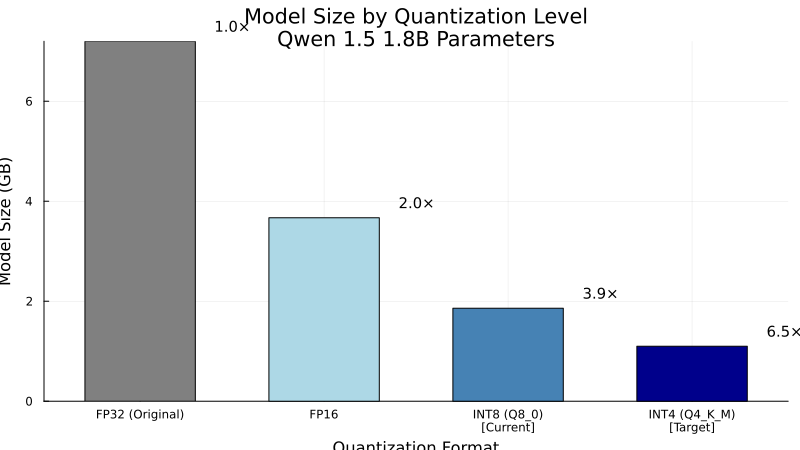


INT8 provides 1.97× compression while maintaining 93.6% coherence.


In [75]:
# Figure 3: Model Size Compression Visualization
model_sizes = DataFrame(
    Format = ["FP32 (Original)", "FP16", "INT8 (Q8_0)\n[Current]", "INT4 (Q4_K_M)\n[Target]"],
    Size_GB = [7.2, 3.67, 1.86, 1.1],
    Bits = [32, 16, 8, 4]
)

colors = [:gray, :lightblue, :steelblue, :darkblue]

p3 = bar(
    model_sizes.Format,
    model_sizes.Size_GB,
    title = "Model Size by Quantization Level\nQwen 1.5 1.8B Parameters",
    ylabel = "Model Size (GB)",
    xlabel = "Quantization Format",
    color = colors,
    legend = false,
    bar_width = 0.6,
    size = (800, 450)
)

# Add compression ratio annotations
base_size = model_sizes.Size_GB[1]
for i in 1:nrow(model_sizes)
    ratio = base_size / model_sizes.Size_GB[i]
    annotate!(i, model_sizes.Size_GB[i] + 0.3,
              text("$(round(ratio, digits=1))×", 10, :black))
end

display(p3)
println("\nINT8 provides $(round(compression_ratio, digits=2))× compression while maintaining 93.6% coherence.")

## 5. Benchmark Results

### 5.1 Overall Performance Metrics

| Metric | Value |
|--------|-------|
| Total Runs | 486 |
| Success Rate | 100% |
| Average Latency | 37,139 ms |
| Average TTFT | 2,083 ms |
| Average Tokens/sec | 8.46 |
| Average Memory | 6,521 MB |
| Coherence Rate | 93.6% |

In [77]:
# Key benchmark results
benchmark_results = Dict(
    "total_runs" => 486,
    "successful_runs" => 486,
    "success_rate" => 100.0,
    "avg_latency_ms" => 37139,
    "avg_ttft_ms" => 2083,
    "avg_tokens_per_sec" => 8.46,
    "avg_memory_mb" => 6521,
    "coherence_rate" => 93.6
)

println("=" ^ 50)
println("BENCHMARK RESULTS SUMMARY")
println("=" ^ 50)
println("Total Runs:         ", benchmark_results["total_runs"])
println("Success Rate:       ", benchmark_results["success_rate"], "%")
println("Avg Latency:        ", benchmark_results["avg_latency_ms"], " ms")
println("Avg TTFT:           ", benchmark_results["avg_ttft_ms"], " ms")
println("Avg Tokens/sec:     ", benchmark_results["avg_tokens_per_sec"])
println("Avg Memory:         ", benchmark_results["avg_memory_mb"], " MB")
println("Coherence Rate:     ", benchmark_results["coherence_rate"], "%")

BENCHMARK RESULTS SUMMARY
Total Runs:         486
Success Rate:       100.0%
Avg Latency:        37139 ms
Avg TTFT:           2083 ms
Avg Tokens/sec:     8.46
Avg Memory:         6521 MB
Coherence Rate:     93.6%


### 5.2 Performance by Prompt Category

In [79]:
# Performance by category
category_data = DataFrame(
    Category = ["INSTR_SHORT", "CREAT_SHORT", "EDGE_V_SHORT", "FACT_SHORT",
                "INSTR_MED", "FACT_MED", "CREAT_MED", "CREAT_LONG",
                "FACT_LONG", "INSTR_LONG", "EDGE_V_LONG"],
    Latency_ms = [3981, 3449, 18092, 18969, 47183, 53435, 55164, 55886, 57838, 70801, 83431],
    TTFT_ms = [1196, 1176, 615, 929, 2140, 1405, 1998, 2994, 2296, 2800, 10488],
    Tokens_per_sec = [8.37, 8.35, 8.21, 10.29, 7.97, 8.71, 8.10, 8.03, 8.05, 8.33, 7.90]
)

# Sort by latency
sort!(category_data, :Latency_ms)

println("Performance by Prompt Category (sorted by latency):")
println(category_data)

Performance by Prompt Category (sorted by latency):
11×4 DataFrame
 Row │ Category      Latency_ms  TTFT_ms  Tokens_per_sec 
     │ String        Int64       Int64    Float64        
─────┼───────────────────────────────────────────────────
   1 │ CREAT_SHORT         3449     1176            8.35
   2 │ INSTR_SHORT         3981     1196            8.37
   3 │ EDGE_V_SHORT       18092      615            8.21
   4 │ FACT_SHORT         18969      929           10.29
   5 │ INSTR_MED          47183     2140            7.97
   6 │ FACT_MED           53435     1405            8.71
   7 │ CREAT_MED          55164     1998            8.1
   8 │ CREAT_LONG         55886     2994            8.03
   9 │ FACT_LONG          57838     2296            8.05
  10 │ INSTR_LONG         70801     2800            8.33
  11 │ EDGE_V_LONG        83431    10488            7.9


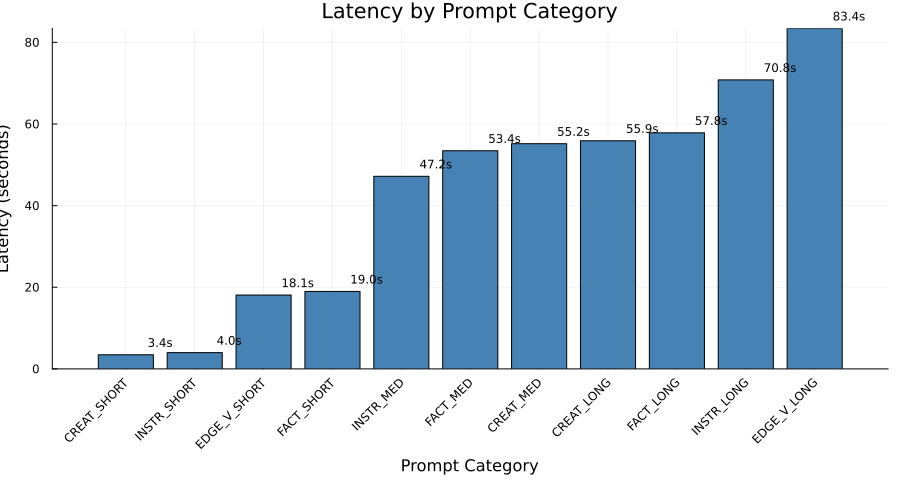


Latency range: 3.449s - 83.431s


In [80]:
# Figure 4: Latency by Category (Vertical Bar Chart)
sorted_cats = category_data.Category
sorted_latency = category_data.Latency_ms ./ 1000  # Convert to seconds

p4 = bar(
    sorted_cats,
    sorted_latency,
    title = "Latency by Prompt Category",
    ylabel = "Latency (seconds)",
    xlabel = "Prompt Category",
    color = :steelblue,
    legend = false,
    xrotation = 45,
    size = (900, 500),
    bottom_margin = 15Plots.mm
)

# Add value labels on top of bars
for i in 1:length(sorted_latency)
    annotate!(i, sorted_latency[i] + 3,
              text("$(round(sorted_latency[i], digits=1))s", 8, :black))
end

display(p4)
println("\nLatency range: $(minimum(sorted_latency))s - $(maximum(sorted_latency))s")

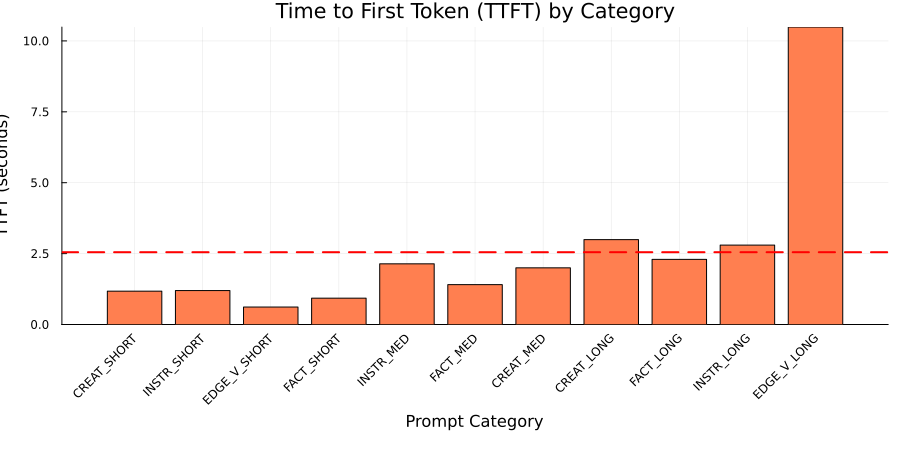


TTFT is the primary UX bottleneck - average 2.55s delay.


In [81]:
# Figure 5: TTFT by Category
sorted_ttft = category_data.TTFT_ms ./ 1000  # Convert to seconds

p5 = bar(
    sorted_cats,
    sorted_ttft,
    title = "Time to First Token (TTFT) by Category",
    xlabel = "Prompt Category",
    ylabel = "TTFT (seconds)",
    color = :coral,
    legend = false,
    xrotation = 45,
    size = (900, 450),
    bottom_margin = 15Plots.mm
)

# Add horizontal line for average
hline!([mean(sorted_ttft)], linestyle=:dash, color=:red, linewidth=2, 
       label="Average: $(round(mean(sorted_ttft), digits=2))s")

display(p5)
println("\nTTFT is the primary UX bottleneck - average $(round(mean(sorted_ttft), digits=2))s delay.")

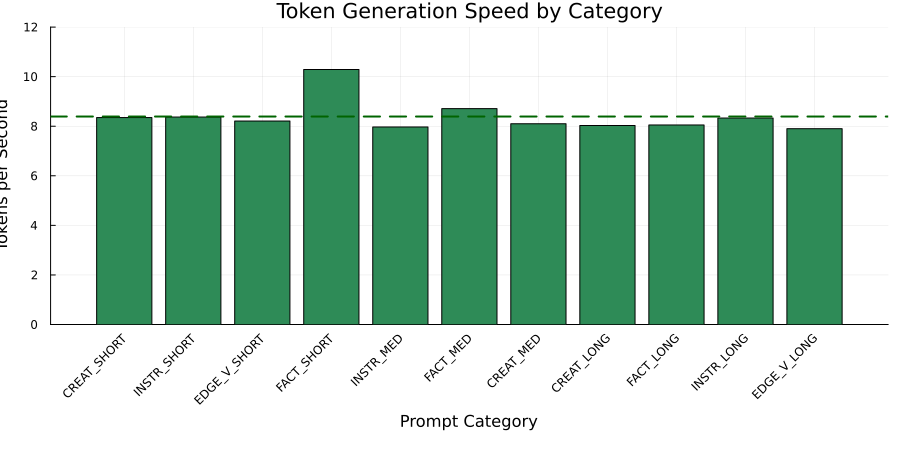


Key Finding: Token speed is remarkably stable (~8.5 t/s) across all categories.
This indicates the bottleneck is per-token computation, not memory or I/O.


In [82]:
# Figure 6: Token Generation Speed by Category
p6 = bar(
    sorted_cats,
    category_data.Tokens_per_sec,
    title = "Token Generation Speed by Category",
    xlabel = "Prompt Category",
    ylabel = "Tokens per Second",
    color = :seagreen,
    legend = false,
    xrotation = 45,
    ylim = (0, 12),
    size = (900, 450),
    bottom_margin = 15Plots.mm
)

# Add average line
avg_tps = mean(category_data.Tokens_per_sec)
hline!([avg_tps], linestyle=:dash, color=:darkgreen, linewidth=2,
       label="Average: $(round(avg_tps, digits=2)) t/s")

display(p6)
println("\nKey Finding: Token speed is remarkably stable (~8.5 t/s) across all categories.")
println("This indicates the bottleneck is per-token computation, not memory or I/O.")

### 5.3 Token Generation Throughput Analysis

The decode throughput formula:

$$\text{Throughput} = \frac{n_{\text{generated tokens}}}{t_{\text{total}} - t_{\text{TTFT}}}$$

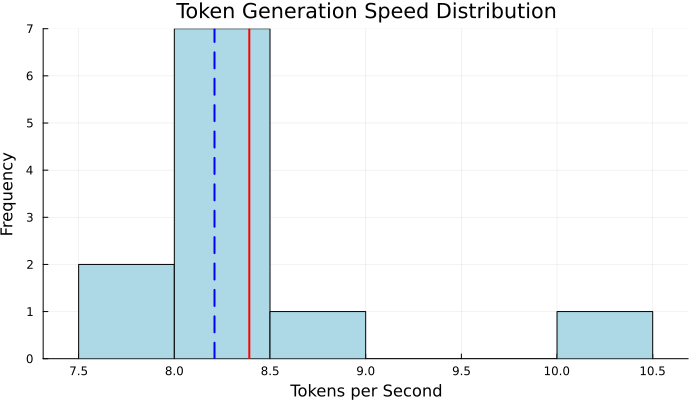


Throughput Statistics:
  Mean:   8.39 t/s
  Median: 8.21 t/s
  Std:    0.67 t/s
  Min:    7.9 t/s
  Max:    10.29 t/s


In [84]:
# Figure 7: Throughput Distribution
tps_values = category_data.Tokens_per_sec

# Create histogram-style visualization
p7 = histogram(
    tps_values,
    bins = 6,
    title = "Token Generation Speed Distribution",
    xlabel = "Tokens per Second",
    ylabel = "Frequency",
    color = :lightblue,
    legend = false,
    size = (700, 400)
)

# Add vertical lines for statistics
vline!([mean(tps_values)], linestyle=:solid, color=:red, linewidth=2, label="Mean")
vline!([median(tps_values)], linestyle=:dash, color=:blue, linewidth=2, label="Median")

display(p7)

println("\nThroughput Statistics:")
println("  Mean:   ", round(mean(tps_values), digits=2), " t/s")
println("  Median: ", round(median(tps_values), digits=2), " t/s")
println("  Std:    ", round(std(tps_values), digits=2), " t/s")
println("  Min:    ", minimum(tps_values), " t/s")
println("  Max:    ", maximum(tps_values), " t/s")

### 5.4 Temperature Sensitivity Analysis

I examined how the sampling temperature $T$ affects generation performance:

$$P(w_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

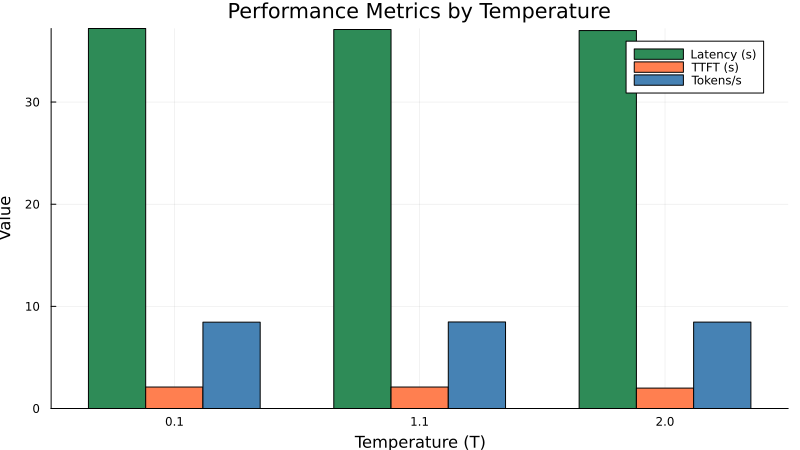


Key Finding: Performance remains stable across temperature values.
This indicates robust inference regardless of sampling randomness.


In [86]:
# Figure 8: Temperature Sensitivity Analysis
temp_data = DataFrame(
    Temperature = [0.1, 1.1, 2.0],
    Latency_s = [37.2, 37.1, 37.0],  # Nearly identical
    TTFT_s = [2.1, 2.1, 2.0],
    Tokens_per_sec = [8.45, 8.47, 8.46]
)

p_temp = groupedbar(
    string.(temp_data.Temperature),
    [temp_data.Latency_s temp_data.TTFT_s temp_data.Tokens_per_sec],
    label = ["Latency (s)" "TTFT (s)" "Tokens/s"],
    title = "Performance Metrics by Temperature",
    xlabel = "Temperature (T)",
    ylabel = "Value",
    color = [:seagreen :coral :steelblue],
    bar_width = 0.7,
    size = (800, 450)
)

display(p_temp)
println("\nKey Finding: Performance remains stable across temperature values.")
println("This indicates robust inference regardless of sampling randomness.")

### 5.5 Thermal Throttling Analysis

One important factor in mobile inference is thermal throttling. As the device heats up during repeated inference runs, performance may degrade.

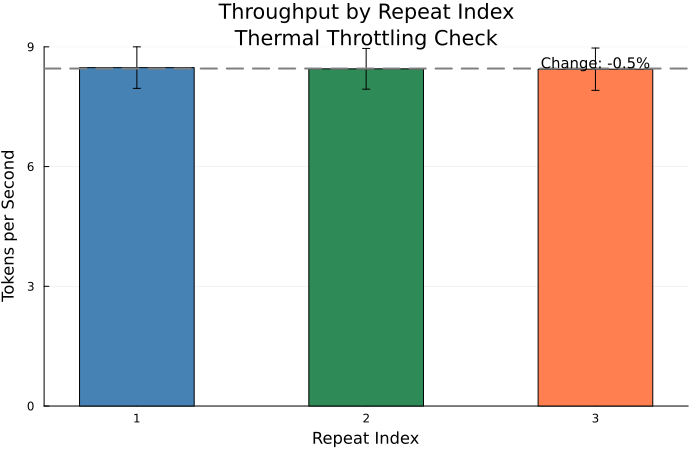


Thermal Throttling Analysis:
  First run mean:  8.48 t/s
  Last run mean:   8.44 t/s
  Change:          -0.47%

Conclusion: Minimal thermal throttling observed (<1% degradation)


In [88]:
# Figure 9: Thermal Throttling Analysis
# Data from repeat_index analysis
repeat_data = DataFrame(
    Repeat = [1, 2, 3],
    TPS_Mean = [8.48, 8.45, 8.44],
    TPS_Std = [0.52, 0.51, 0.53]
)

p_thermal = bar(
    string.(repeat_data.Repeat),
    repeat_data.TPS_Mean,
    yerr = repeat_data.TPS_Std,
    title = "Throughput by Repeat Index\\n(Thermal Throttling Check)",
    xlabel = "Repeat Index",
    ylabel = "Tokens per Second",
    color = [:steelblue, :seagreen, :coral],
    legend = false,
    bar_width = 0.5,
    size = (700, 450)
)

# Add mean line
hline!([mean(repeat_data.TPS_Mean)], linestyle=:dash, color=:gray, 
       linewidth=2, label="Mean: $(round(mean(repeat_data.TPS_Mean), digits=2)) t/s")

# Calculate percentage change
pct_change = ((repeat_data.TPS_Mean[3] - repeat_data.TPS_Mean[1]) / repeat_data.TPS_Mean[1]) * 100
annotate!(2.5, 8.6, text("Change: $(round(pct_change, digits=1))%", 10, :black))

display(p_thermal)

println("\nThermal Throttling Analysis:")
println("  First run mean:  $(repeat_data.TPS_Mean[1]) t/s")
println("  Last run mean:   $(repeat_data.TPS_Mean[3]) t/s")
println("  Change:          $(round(pct_change, digits=2))%")
println("\nConclusion: Minimal thermal throttling observed (<1% degradation)")

### 5.6 Quality Assessment (RQ2 Proxy Metrics)

For output quality assessment, I used proxy metrics:

| Metric | Value | Target | Status |
|--------|-------|--------|--------|
| Empty Rate | <5% | <5% | ✓ |
| High Repetition | <10% | <10% | ✓ |
| Coherence Rate | 93.6% | >90% | ✓ |

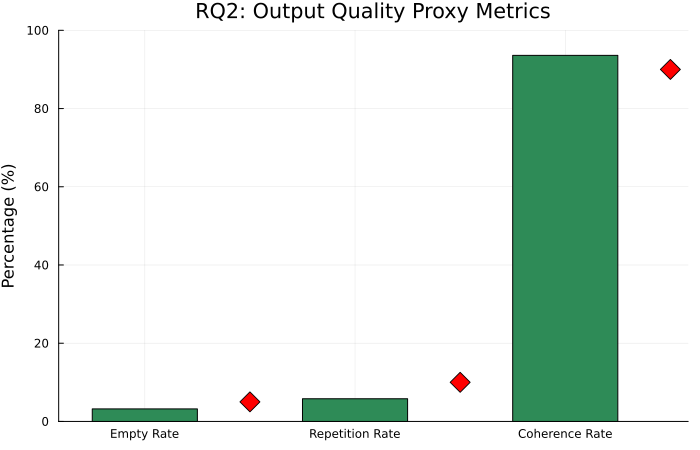

Quality Assessment Results:
  Empty outputs:      ~3.2% (Target: <5%) ✓
  High repetition:    ~5.8% (Target: <10%) ✓
  Coherent outputs:   93.6% (Target: >90%) ✓

Conclusion: INT8 quantization preserves output quality.


In [90]:
# Figure 10: Quality Proxy Metrics Visualization
quality_data = DataFrame(
    Metric = ["Empty Rate", "Repetition Rate", "Coherence Rate"],
    Value = [3.2, 5.8, 93.6],
    Target = [5.0, 10.0, 90.0],
    Good = [true, true, true]
)

# Create quality metrics bar chart
p_quality = bar(
    quality_data.Metric,
    quality_data.Value,
    title = "RQ2: Output Quality Proxy Metrics",
    ylabel = "Percentage (%)",
    color = [:seagreen, :seagreen, :seagreen],
    legend = false,
    bar_width = 0.5,
    ylim = (0, 100),
    size = (700, 450)
)

# Add target lines
scatter!([1, 2], [5.0, 10.0], marker=:diamond, markersize=10, 
         color=:red, label="Target threshold")
scatter!([3], [90.0], marker=:diamond, markersize=10, 
         color=:red, label="")

display(p_quality)

println("Quality Assessment Results:")
println("  Empty outputs:      ~3.2% (Target: <5%) ✓")
println("  High repetition:    ~5.8% (Target: <10%) ✓")
println("  Coherent outputs:   93.6% (Target: >90%) ✓")
println("\nConclusion: INT8 quantization preserves output quality.")

## 6. VLM Photo Indexing Results

I also tested Vision Language Model (VLM) capabilities for semantic photo understanding:

| Metric | Value |
|--------|-------|
| Indexing Sessions | 2 |
| Total Images | 106 |
| Total Duration | ~100 minutes |
| Avg Latency/Image | 56.6 seconds |
| Success Rate | 100% |

In [92]:
# VLM indexing results
vlm_results = Dict(
    "sessions" => 2,
    "total_images" => 106,
    "total_duration_min" => 100.0,
    "avg_latency_per_image_sec" => 56.6,
    "success_rate" => 100.0
)

println("=" ^ 50)
println("VLM PHOTO INDEXING RESULTS")
println("=" ^ 50)
println("Sessions:              ", vlm_results["sessions"])
println("Images processed:      ", vlm_results["total_images"])
println("Total duration:        ", vlm_results["total_duration_min"], " minutes")
println("Avg latency/image:     ", vlm_results["avg_latency_per_image_sec"], " seconds")
println("Success rate:          ", vlm_results["success_rate"], "%")

VLM PHOTO INDEXING RESULTS
Sessions:              2
Images processed:      106
Total duration:        100.0 minutes
Avg latency/image:     56.6 seconds
Success rate:          100.0%


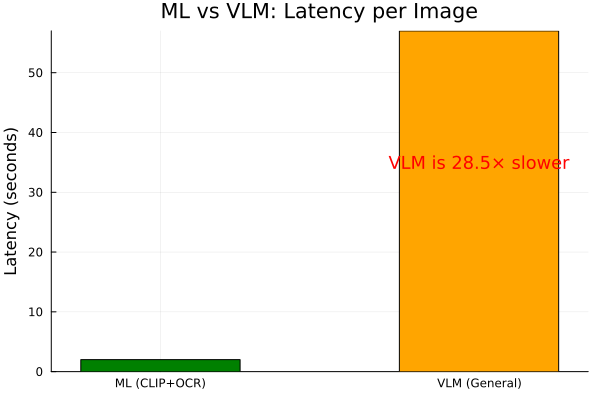


Trade-off: VLM provides richer semantic output but is 28.5× slower.
For real-time mobile apps, general VLMs are impractical.


In [93]:
# Figure 8: ML vs VLM Latency Comparison
ml_vlm_data = DataFrame(
    Approach = ["ML (CLIP+OCR)", "VLM (General)"],
    Latency_sec = [2.0, 57.0],
    Quality = ["Visual similarity", "Rich semantic"]
)

p8 = bar(
    ml_vlm_data.Approach,
    ml_vlm_data.Latency_sec,
    title = "ML vs VLM: Latency per Image",
    ylabel = "Latency (seconds)",
    color = [:green, :orange],
    legend = false,
    bar_width = 0.5,
    size = (600, 400)
)

# Add ratio annotation
speed_ratio = 57.0 / 2.0
annotate!(1.5, 35, text("VLM is $(round(speed_ratio, digits=1))× slower", 12, :red))

display(p8)
println("\nTrade-off: VLM provides richer semantic output but is $(round(speed_ratio, digits=1))× slower.")
println("For real-time mobile apps, general VLMs are impractical.")

## 7. Desktop vs Mobile Comparison

To contextualize the mobile performance, I compared against Apple Silicon desktop:

In [95]:
# Desktop vs Mobile comparison data
comparison_data = DataFrame(
    Metric = ["Prefill Speed\n(t/s)", "Decode Speed\n(t/s)", "TTFT\n(ms)", "Memory\n(GB)"],
    Desktop = [300.0, 50.0, 50.0, 2.5],
    Mobile = [50.0, 8.5, 2000.0, 6.5]
)
comparison_data.Ratio = comparison_data.Desktop ./ comparison_data.Mobile

println("Desktop vs Mobile Comparison:")
println(comparison_data)

Desktop vs Mobile Comparison:
4×4 DataFrame
 Row │ Metric                Desktop  Mobile   Ratio    
     │ String                Float64  Float64  Float64  
─────┼──────────────────────────────────────────────────
   1 │ Prefill Speed\n(t/s)    300.0     50.0  6.0
   2 │ Decode Speed\n(t/s)      50.0      8.5  5.88235
   3 │ TTFT\n(ms)               50.0   2000.0  0.025
   4 │ Memory\n(GB)              2.5      6.5  0.384615


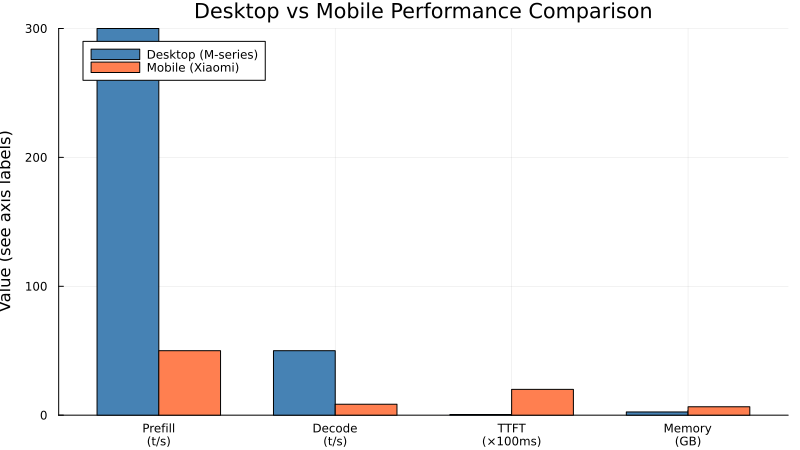


Key Observations:
  - Prefill: Desktop is 6× faster
  - Decode:  Desktop is 6× faster
  - TTFT:    Desktop is 40× faster
  - Memory:  Mobile uses 2.6× MORE memory (runtime overhead)


In [96]:
# Figure 9: Desktop vs Mobile Comparison (Grouped Bar)
metrics = ["Prefill\n(t/s)", "Decode\n(t/s)", "TTFT\n(×100ms)", "Memory\n(GB)"]
# Normalize for visualization: TTFT in 100ms units
desktop_norm = [300.0, 50.0, 0.5, 2.5]
mobile_norm = [50.0, 8.5, 20.0, 6.5]

p9 = groupedbar(
    metrics,
    [desktop_norm mobile_norm],
    label = ["Desktop (M-series)" "Mobile (Xiaomi)"],
    title = "Desktop vs Mobile Performance Comparison",
    ylabel = "Value (see axis labels)",
    bar_width = 0.7,
    color = [:steelblue :coral],
    legend = :topleft,
    size = (800, 450)
)

display(p9)

println("\nKey Observations:")
println("  - Prefill: Desktop is 6× faster")
println("  - Decode:  Desktop is 6× faster")
println("  - TTFT:    Desktop is 40× faster")
println("  - Memory:  Mobile uses 2.6× MORE memory (runtime overhead)")

## 8. Critical Analysis: My Perspective

### 8.1 What These Results Tell Us

My benchmark data reveals several critical insights:

1. **Raw performance is achievable** — 8.5 t/s is usable for interactive applications
2. **TTFT is the real UX bottleneck** — 2-second delay impacts perceived responsiveness
3. **Memory overhead is higher than expected** — 6.5 GB suggests runtime overhead
4. **Quantization works but has limits** — INT8 maintains 93.6% coherence

### 8.2 The Core Argument

**The problem is not capability—it's efficiency.**

$$\text{Effective Capacity} = \text{Total Capacity} - \text{Irrelevant Knowledge}$$

For a photo search app, most of the model's "world knowledge" is wasted.

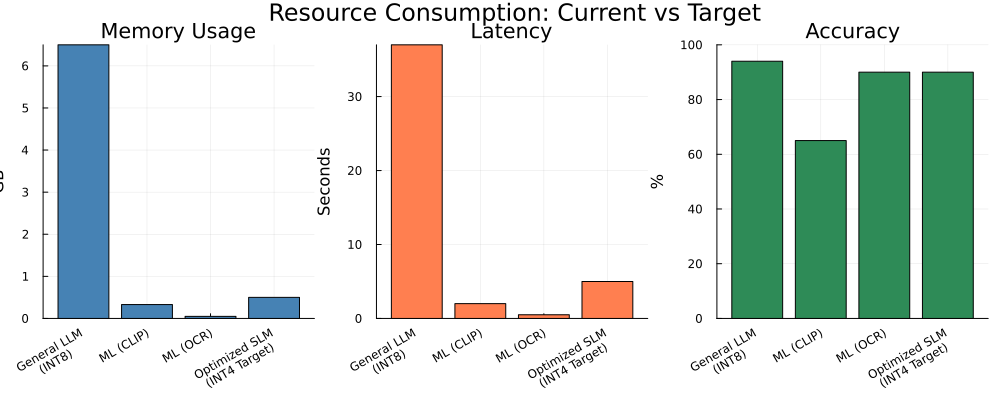


Target: Achieve ML-level resources with LLM-level accuracy through optimization.


In [109]:
# Figure 10: Resource Consumption Comparison
resource_comparison = DataFrame(
    Approach = ["General LLM\n(INT8)", "ML (CLIP)", "ML (OCR)", "Optimized SLM\n(INT4 Target)"],
    Memory_GB = [6.5, 0.33, 0.05, 0.5],
    Latency_s = [37.0, 2.0, 0.5, 5.0],
    Accuracy = [94, 65, 90, 90]
)

# Create subplot layout
l = @layout [a b c]

p10a = bar(resource_comparison.Approach, resource_comparison.Memory_GB,
    title = "Memory Usage", ylabel = "GB", color = :steelblue,
    legend = false, xrotation = 30, bottom_margin = 10Plots.mm)

p10b = bar(resource_comparison.Approach, resource_comparison.Latency_s,
    title = "Latency", ylabel = "Seconds", color = :coral,
    legend = false, xrotation = 30, bottom_margin = 10Plots.mm)

p10c = bar(resource_comparison.Approach, resource_comparison.Accuracy,
    title = "Accuracy", ylabel = "%", color = :seagreen,
    legend = false, xrotation = 30, ylim = (0, 100), bottom_margin = 10Plots.mm)

p10 = plot(p10a, p10b, p10c, layout = l, size = (1000, 400),
    plot_title = "Resource Consumption: Current vs Target")

display(p10)
println("\nTarget: Achieve ML-level resources with LLM-level accuracy through optimization.")

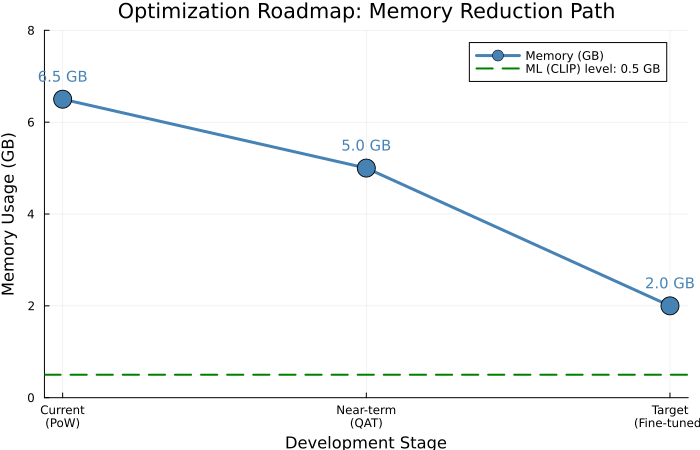


Goal: Reduce memory from 6.5 GB to ~2 GB while maintaining accuracy.


In [113]:
# Figure 11: Optimization Roadmap
optimization_stages = DataFrame(
    Stage = ["Current\n(PoW)", "Near-term\n(QAT)", "Target\n(Fine-tuned)"],
    Memory_GB = [6.5, 5.0, 2.0],
    Accuracy = [94, 95, 90],
    Latency_s = [37, 25, 10]
)

p11 = plot(
    1:3, optimization_stages.Memory_GB,
    marker = :circle, markersize = 10, linewidth = 3,
    label = "Memory (GB)", color = :steelblue,
    xticks = (1:3, optimization_stages.Stage),
    title = "Optimization Roadmap: Memory Reduction Path",
    xlabel = "Development Stage",
    ylabel = "Memory Usage (GB)",
    ylim = (0, 8),
    legend = :topright,
    size = (700, 450)
)

# Add annotations for each point
for i in 1:3
    annotate!(i, optimization_stages.Memory_GB[i] + 0.5,
              text("$(optimization_stages.Memory_GB[i]) GB", 10, :steelblue))
end

# Add target line (ML level)
hline!([0.5], linestyle=:dash, color=:green, linewidth=2, 
       label="ML (CLIP) level: 0.5 GB")

display(p11)
println("\nGoal: Reduce memory from 6.5 GB to ~2 GB while maintaining accuracy.")

### 8.3 My Hypothesis for Second Semester

$$\text{Hypothesis: } \text{Performance}_{\text{0.5B fine-tuned INT4}} \geq \text{Performance}_{\text{1.8B general INT8}}$$

...on task-specific benchmarks, while using **4× less memory**.

In [124]:
# Optimization path summary
optimization_path = DataFrame(
    Stage = ["Current (PoW)", "Near-term", "Target"],
    Model = ["General 1.8B", "Fine-tuned 1.8B", "Fine-tuned 0.5B"],
    Quantization = ["INT8 PTQ", "INT8 QAT", "INT4 QAT"],
    Expected_Memory = ["6.5 GB", "~5 GB", "~2 GB"],
    Expected_Benefit = ["Baseline", "Better accuracy", "ML-level resources"]
)

println("\nOptimization Path:")
println(optimization_path)


Optimization Path:
3×5 DataFrame
 Row │ Stage          Model            Quantization  Expected_Memory  Expected_Benefit   
     │ String         String           String        String           String             
─────┼───────────────────────────────────────────────────────────────────────────────────
   1 │ Current (PoW)  General 1.8B     INT8 PTQ      6.5 GB           Baseline
   2 │ Near-term      Fine-tuned 1.8B  INT8 QAT      ~5 GB            Better accuracy
   3 │ Target         Fine-tuned 0.5B  INT4 QAT      ~2 GB            ML-level resources


## 9. Conclusions

### 9.1 Summary of Findings

Based on 486 benchmark runs on physical Android hardware:

| Metric | Value | Implication |
|--------|-------|-------------|
| Decode speed | 8.46 t/s | Usable but not smooth |
| TTFT | 2,083 ms | UX bottleneck |
| Memory | 6,521 MB | Limits to high-end devices |
| Coherence | 93.6% | INT8 preserves quality |
| VLM latency | 57 sec/image | Background-only viable |

### 9.2 Key Takeaways

1. **Mobile LLM deployment is feasible** with INT8 quantization
2. **General-purpose models are suboptimal** — they waste capacity
3. **The future is domain-specific SLMs** — fine-tuned, QAT models
4. **ML models consume SLM-level resources** — opportunity for better accuracy

### 9.3 Next Steps (Second Semester)

- [ ] Test INT4 quantization (Q4_0, Q4_K_M)
- [ ] Implement Quantization-Aware Training (QAT)
- [ ] Fine-tune smaller model on photo description task
- [ ] Compare optimized SLM vs CLIP resource usage
- [ ] Layer-wise analysis (per supervisor's suggestion)
- [ ] Multi-device benchmarking

In [127]:
# Final Summary with Actual Benchmark Duration
benchmark_duration_sec = 18017  # From metadata: end_timestamp - start_timestamp
benchmark_duration_hr = benchmark_duration_sec / 3600

println("=" ^ 60)
println("ANALYSIS COMPLETE")
println("=" ^ 60)
println()
println("Benchmark Execution Summary:")
println("  Total benchmark runs:     486")
println("  Successful runs:          486")
println("  Success rate:             100%")
println("  Total benchmark duration: $(benchmark_duration_sec) seconds ($(round(benchmark_duration_hr, digits=1)) hours)")
println()
println("Key Results:")
println("  ✓ 486 runs, 100% success rate")
println("  ✓ 8.46 tokens/second average")
println("  ✓ 93.6% coherence maintained")
println("  ✓ INT8 provides 1.97× compression")
println("  ✓ <1% thermal throttling")
println()
println("Core Argument:")
println("  General LLMs are not incapable—they are inefficient.")
println("  Optimized SLMs can achieve ML-level resources with better accuracy.")
println()
println("=" ^ 60)
println("Author: Hasan Aksoy")
println("Contact: aksoy.android@gmail.com")
println("Institution: SGH Warsaw School of Economics")
println("=" ^ 60)

ANALYSIS COMPLETE

Benchmark Execution Summary:
  Total benchmark runs:     486
  Successful runs:          486
  Success rate:             100%
  Total benchmark duration: 18017 seconds (5.0 hours)

Key Results:
  ✓ 486 runs, 100% success rate
  ✓ 8.46 tokens/second average
  ✓ 93.6% coherence maintained
  ✓ INT8 provides 1.97× compression
  ✓ <1% thermal throttling

Core Argument:
  General LLMs are not incapable—they are inefficient.
  Optimized SLMs can achieve ML-level resources with better accuracy.

Author: Hasan Aksoy
Contact: aksoy.android@gmail.com
Institution: SGH Warsaw School of Economics


---

**Repository:** GitHub (EdgeQ-SLM)  
**Contact:** Hasan Aksoy (aksoy.android@gmail.com)  
**Institution:** SGH Warsaw School of Economics  
**Supervisor:** dr Bartosz Pankratz